## Student-Performance-Prediction/

    │
    ├── data/
    │   └── student.csv
    │
    ├── notebooks/
    │   └── EDA.ipynb
    │
    ├── src/
    │   ├── train.py
    │   ├── predict.py
    │   └── preprocessing.py
    │
    ├── models/
    │   └── model.pkl
    │
    ├── app.py
    │
    ├── requirements.txt
    │
    ├── Dockerfile
    │
    └── README.md

## EDA

#### Load Dataset

In [8]:
import pandas as pd

In [9]:
df = pd.read_csv("C:/Users/manda/MACHINE LEARNING/Machine-Learning/Student_performance_data _.csv")

#### Missing Values

In [11]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [12]:
df.head()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
0,1001,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196,2.0
1,1002,18,0,0,1,15.408756,0,0,1,0,0,0,0,3.042915,1.0
2,1003,15,0,2,3,4.210570,26,0,2,0,0,0,0,0.112602,4.0
3,1004,17,1,0,3,10.028829,14,0,3,1,0,0,0,2.054218,3.0
4,1005,17,1,0,2,4.672495,17,1,3,0,0,0,0,1.288061,4.0


In [13]:
df.shape

(2392, 15)

In [14]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2392 entries, 0 to 2391
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   StudentID          2392 non-null   int64  
 1   Age                2392 non-null   int64  
 2   Gender             2392 non-null   int64  
 3   Ethnicity          2392 non-null   int64  
 4   ParentalEducation  2392 non-null   int64  
 5   StudyTimeWeekly    2392 non-null   float64
 6   Absences           2392 non-null   int64  
 7   Tutoring           2392 non-null   int64  
 8   ParentalSupport    2392 non-null   int64  
 9   Extracurricular    2392 non-null   int64  
 10  Sports             2392 non-null   int64  
 11  Music              2392 non-null   int64  
 12  Volunteering       2392 non-null   int64  
 13  GPA                2392 non-null   float64
 14  GradeClass         2392 non-null   float64
dtypes: float64(3), int64(12)
memory usage: 280.4 KB


In [16]:
df.describe()

,StudentID,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA,GradeClass
count,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000,2392.000000
mean,2196.500000,16.468645,0.510870,0.877508,1.746237,9.771992,14.541388,0.301421,2.122074,0.383361,0.303512,0.196906,0.157191,1.906186,2.983696
std,690.655244,1.123798,0.499986,1.028476,1.000411,5.652774,8.467417,0.458971,1.122813,0.486307,0.459870,0.397744,0.364057,0.915156,1.233908
min,1001.000000,15.000000,0.000000,0.000000,0.000000,0.001057,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1598.750000,15.000000,0.000000,0.000000,1.000000,5.043079,7.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,1.174803,2.000000
50%,2196.500000,16.000000,1.000000,0.000000,2.000000,9.705363,15.000000,0.000000,2.000000,0.000000,0.000000,0.000000,0.000000,1.893393,4.000000
75%,2794.250000,17.000000,1.000000,2.000000,2.000000,14.408410,22.000000,1.000000,3.000000,1.000000,1.000000,0.000000,0.000000,2.622216,4.000000
max,3392.000000,18.000000,1.000000,3.000000,4.000000,19.978094,29.000000,1.000000,4.000000,1.000000,1.000000,1.000000,1.000000,4.000000,4.000000


In [17]:
df.isnull().sum()

StudentID            0
Age                  0
Gender               0
Ethnicity            0
ParentalEducation    0
StudyTimeWeekly      0
Absences             0
Tutoring             0
ParentalSupport      0
Extracurricular      0
Sports               0
Music                0
Volunteering         0
GPA                  0
GradeClass           0
dtype: int64

In [30]:
df.duplicated().sum()

0

## Univariate Columns

#### Numerical Columns

In [37]:
df.columns

Index(['StudentID', 'Age', 'Gender', 'Ethnicity', 'ParentalEducation',
       'StudyTimeWeekly', 'Absences', 'Tutoring', 'ParentalSupport',
       'Extracurricular', 'Sports', 'Music', 'Volunteering', 'GPA',
       'GradeClass'],
      dtype='object')

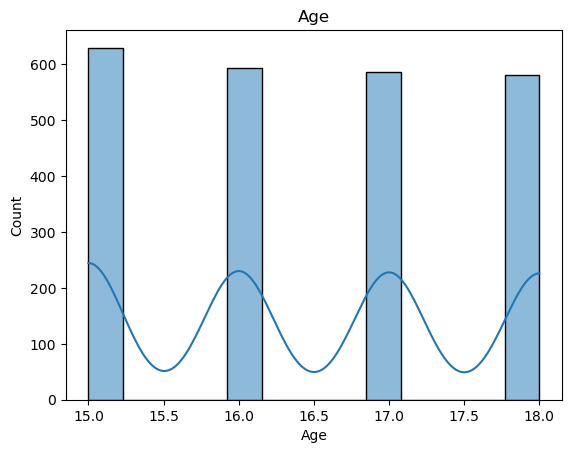

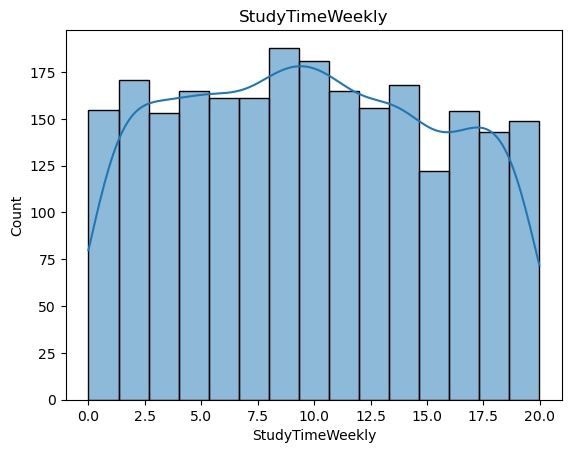

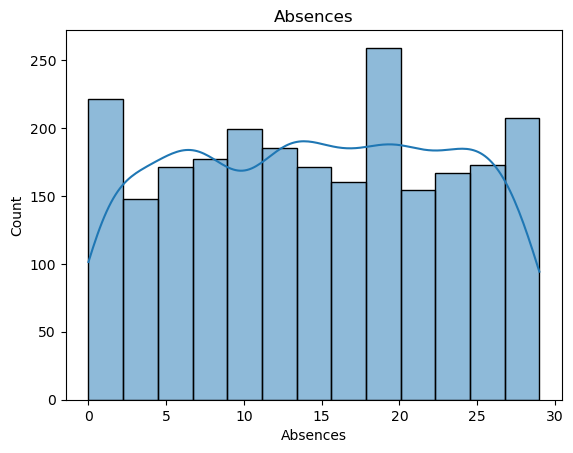

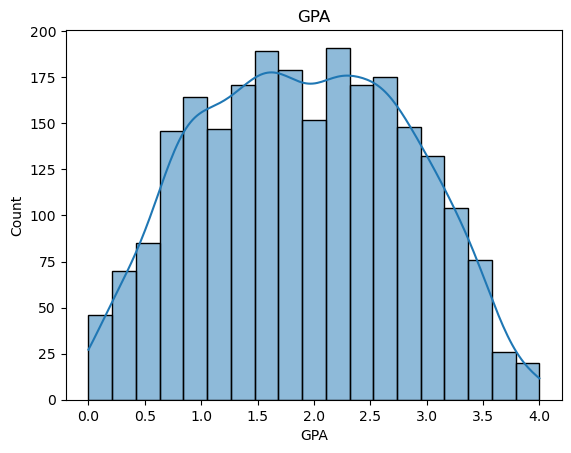

In [41]:
import seaborn as sns
import matplotlib.pyplot as plt 

numerical_cols = [
    'Age',
    'StudyTimeWeekly',
    'Absences',
    'GPA'
]

for col in numerical_cols:
    sns.histplot(df[col], kde=True)
    plt.title(col)
    plt.show()

In [43]:
df['GradeClass'].value_counts()

GradeClass
4.0    1211
3.0     414
2.0     391
1.0     269
0.0     107
Name: count, dtype: int64

## STEP 8: NUMERICAL FEATURE ANALYSIS

#### Numerical Columns:

In [47]:
num_cols = [
    "Age",
    "StudyTimeWeekly",
    "Absences",
    "GPA"
]

## Histograms

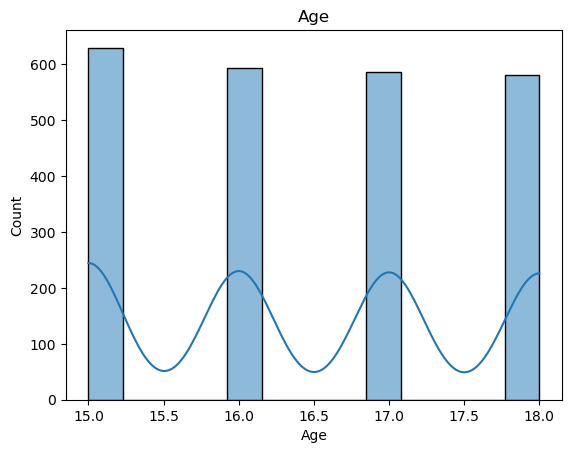

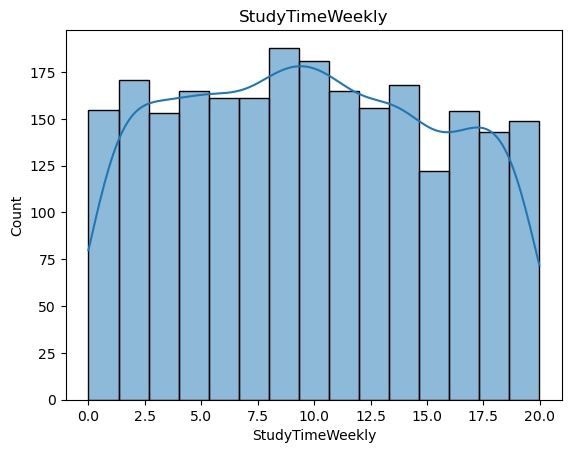

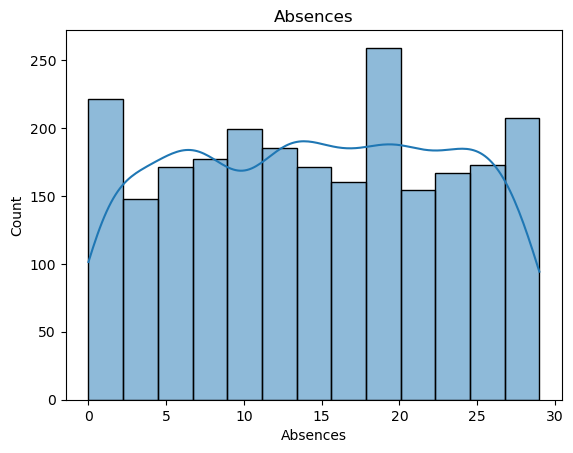

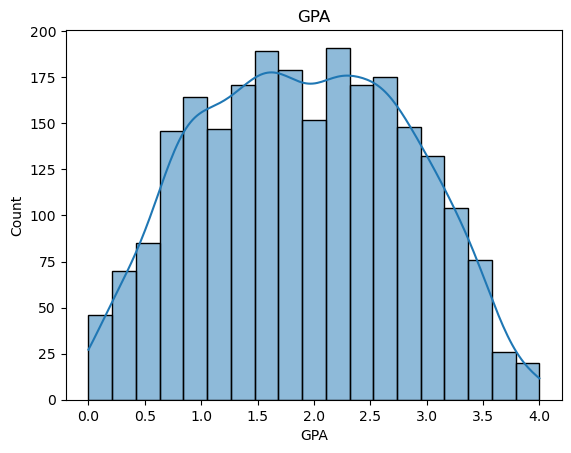

In [50]:
for col in num_cols:

    sns.histplot(
        df[col],
        kde=True
    )

    plt.title(col)

    plt.show()

### STEP 9: CATEGORICAL FEATURE ANALYSIS

In [53]:
cat_cols = [
    "Gender",
    "Ethnicity",
    "ParentalEducation",
    "Tutoring",
    "ParentalSupport",
    "Extracurricular",
    "Sports",
    "Music",
    "Volunteering"
]

## Countplots

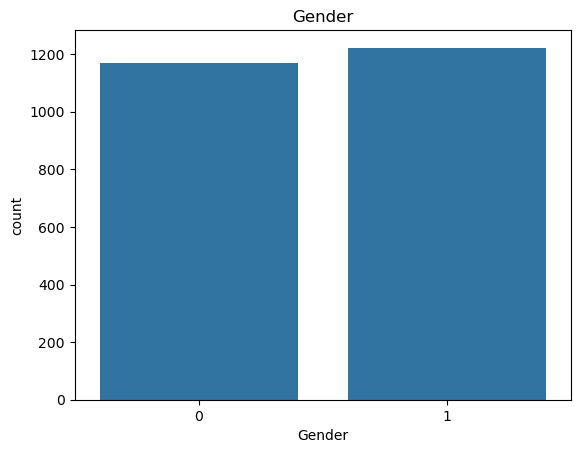

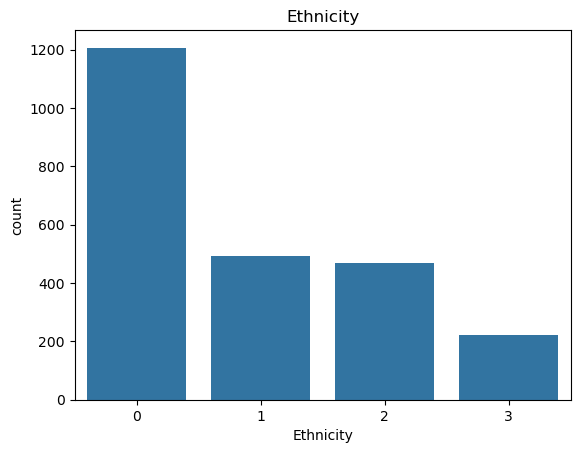

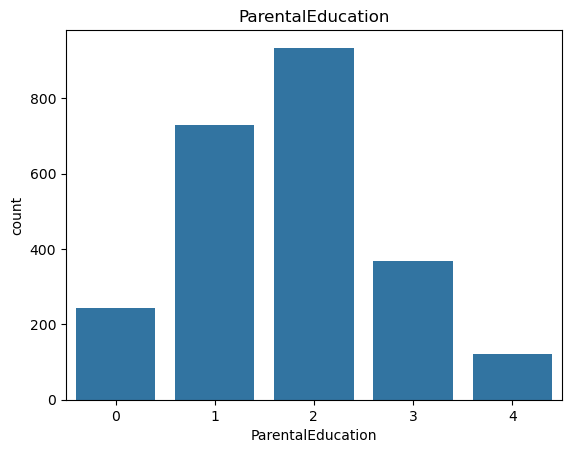

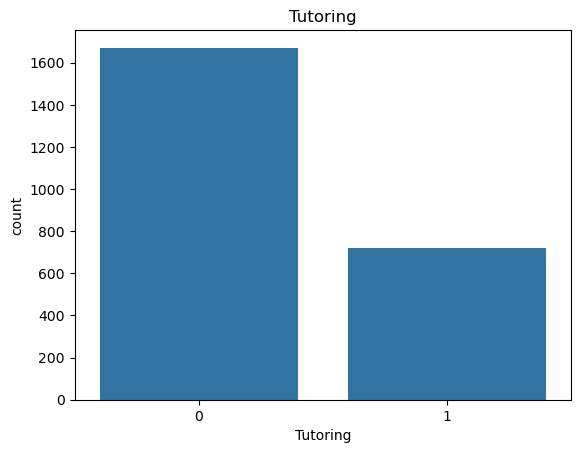

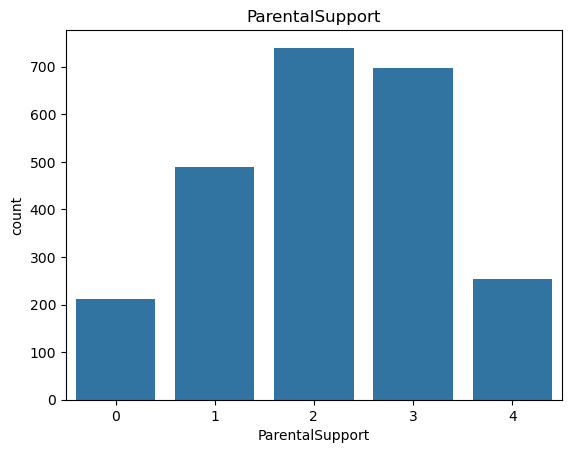

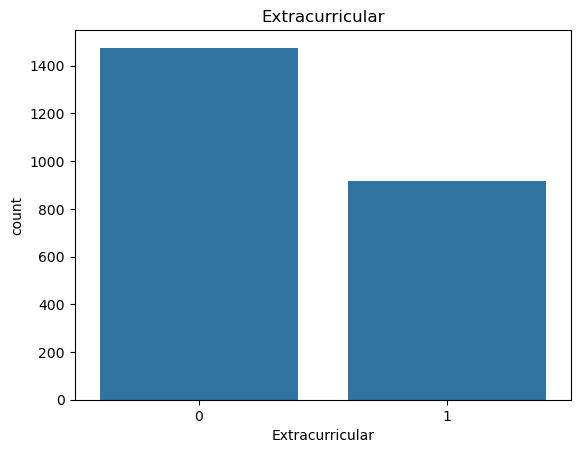

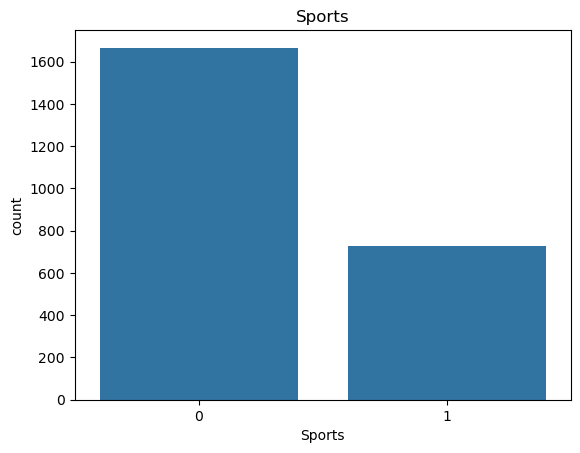

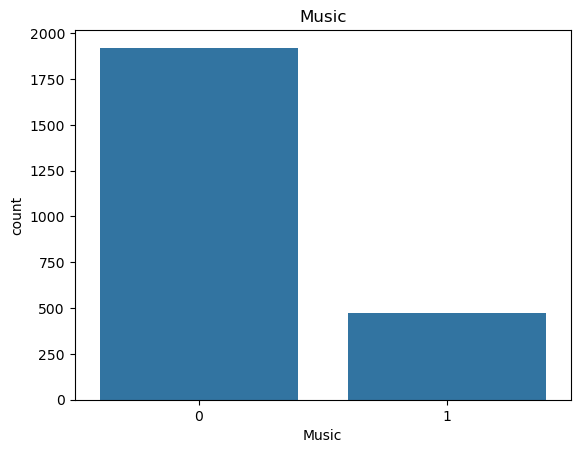

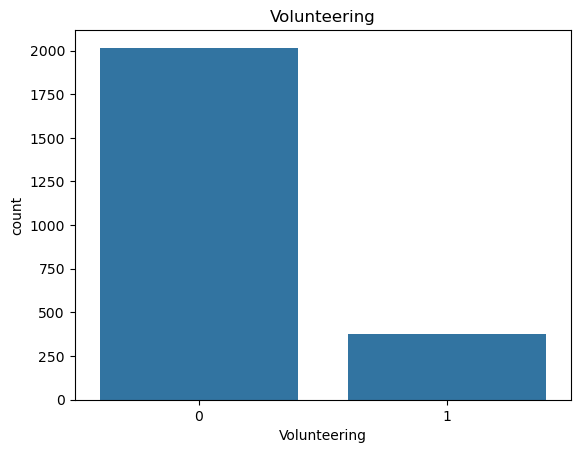

In [56]:
for col in cat_cols:

    sns.countplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

## STEP 10: OUTLIER ANALYSIS

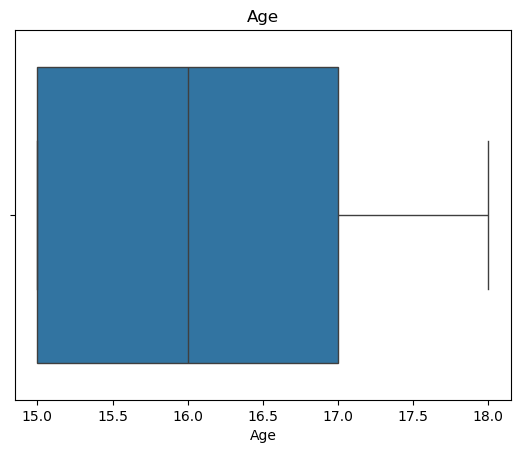

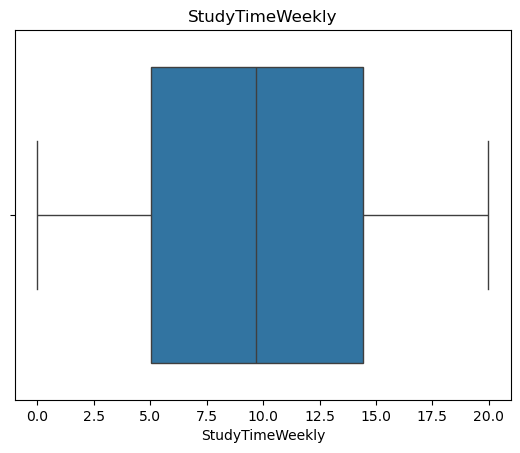

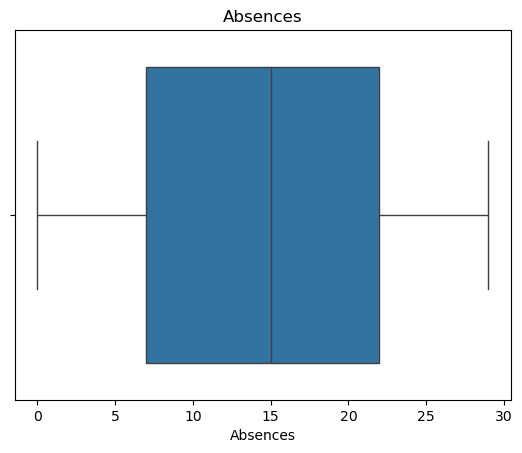

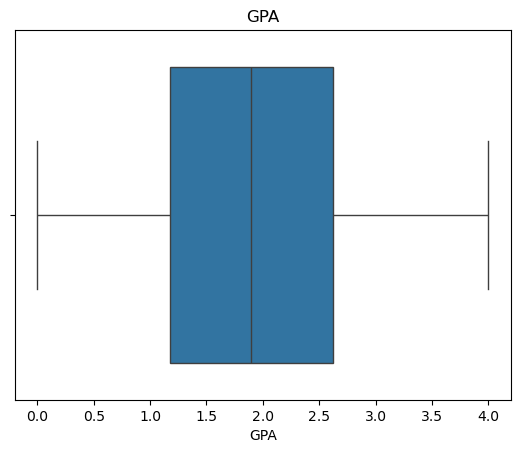

In [59]:
for col in num_cols:

    sns.boxplot(
        x=df[col]
    )

    plt.title(col)

    plt.show()

## STEP 11: BIVARIATE ANALYSIS

### Study Time vs GPA

<Axes: xlabel='StudyTimeWeekly', ylabel='GPA'>

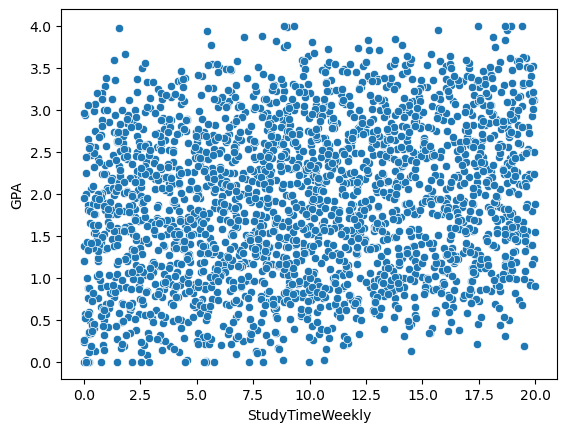

In [63]:
sns.scatterplot(
    x="StudyTimeWeekly",
    y="GPA",
    data=df
)

## Absences vs GPA

<Axes: xlabel='Absences', ylabel='GPA'>

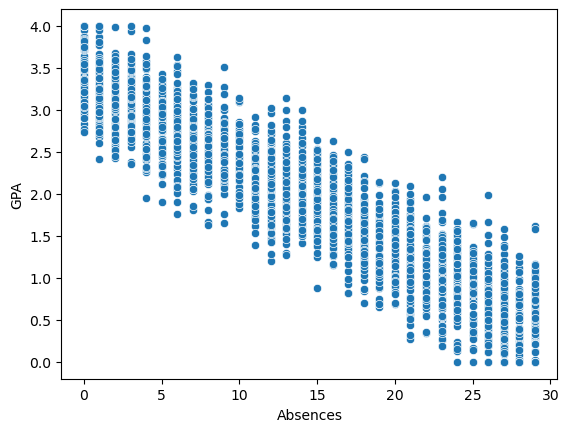

In [66]:
sns.scatterplot(
    x="Absences",
    y="GPA",
    data=df
)

## Gender vs GPA

<Axes: xlabel='Gender', ylabel='GPA'>

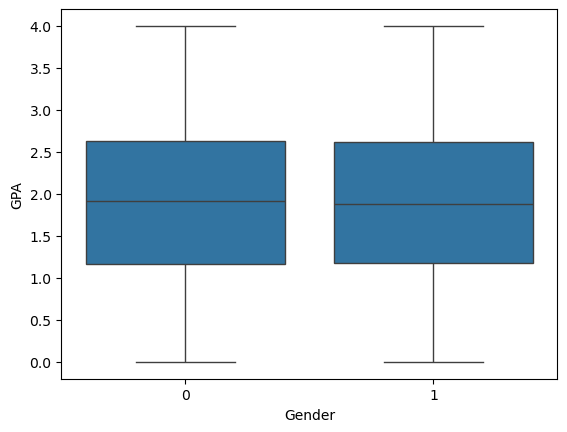

In [69]:
sns.boxplot(
    x="Gender",
    y="GPA",
    data=df
)

## Tutoring vs GPA

<Axes: xlabel='Tutoring', ylabel='GPA'>

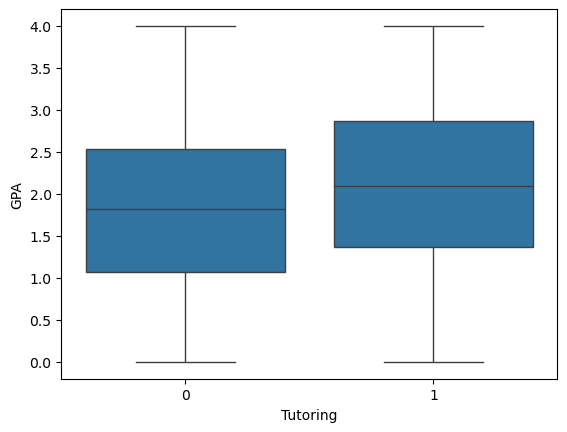

In [72]:
sns.boxplot(
    x="Tutoring",
    y="GPA",
    data=df
)

## STEP 12: CORRELATION ANALYSIS

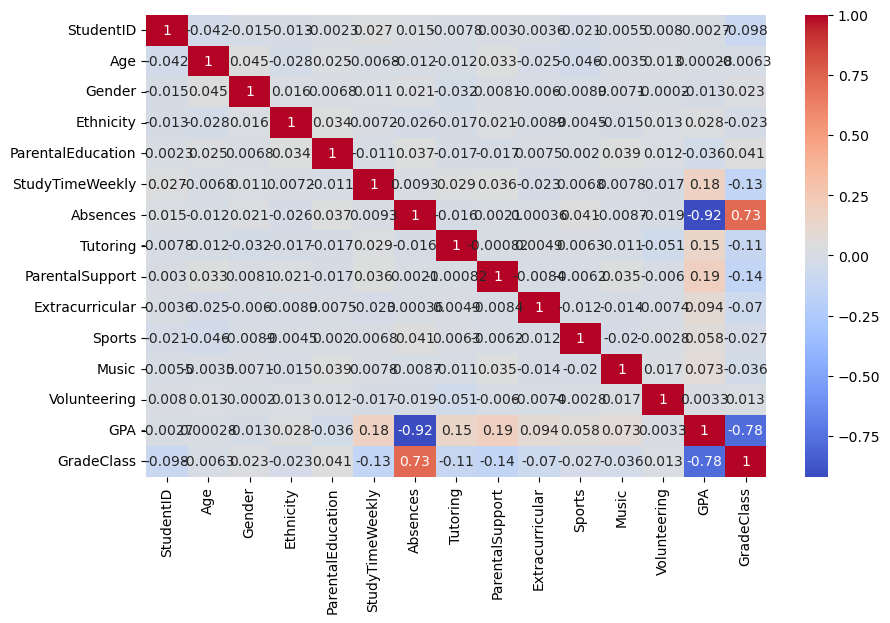

In [75]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap="coolwarm"
)

plt.show()

## STEP 13: EDA REPORT

###
###### 1. GPA positively correlated with StudyTimeWeekly.
###### 2. GPA negatively correlated with Absences.
###### 3. GradeClass is imbalanced.
###### 4. Few outliers exist in Absences.
###### 5. Tutoring students generally achieve better GPA.
###


## PHASE 3: DATA PREPROCESSING

## Step 14: Remove StudentID

In [96]:
df.drop(
    "StudentID",
    axis=1,
    inplace=True
)

## Step 15: Separate Features and Target

In [99]:
X = df.drop(
    "GradeClass",
    axis=1
)

y = df["GradeClass"]

## Step 16: Encode Categorical Columns

In [102]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

In [104]:
for col in X.select_dtypes(
    include="object"
):

    X[col] = le.fit_transform(
        X[col]
    )

## Step 17: Train-Test Split

In [107]:
from sklearn.model_selection import train_test_split

In [109]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

## PHASE 4: MODEL BUILDING

## Step 18: Train Models

## Logistic Regression

In [129]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train, y_train)

C:\Users\manda\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:469: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

## Evaluate Logistic Regression

In [134]:
from sklearn.metrics import accuracy_score

lr_pred = lr_model.predict(X_test)

lr_acc = accuracy_score(y_test, lr_pred)

print("Logistic Regression Accuracy:", lr_acc)

Logistic Regression Accuracy: 0.7432150313152401


## Random Forest

In [131]:
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(random_state=42)

## Evaluate Random Forest

In [138]:
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9144050104384134


## Evaluate Random Forest

In [140]:
rf_pred = rf_model.predict(X_test)

rf_acc = accuracy_score(y_test, rf_pred)

print("Random Forest Accuracy:", rf_acc)

Random Forest Accuracy: 0.9144050104384134


## XGBoost

In [145]:
from xgboost import XGBClassifier
xgb_model = XGBClassifier(
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

## Evaluate XGBoost

In [148]:
xgb_pred = xgb_model.predict(X_test)

xgb_acc = accuracy_score(y_test, xgb_pred)

print("XGBoost Accuracy:", xgb_acc)

XGBoost Accuracy: 0.9123173277661796


## Step 19: Compare Models

In [151]:
print("Logistic Regression :", lr_acc)
print("Random Forest       :", rf_acc)
print("XGBoost             :", xgb_acc)

Logistic Regression : 0.7432150313152401
Random Forest       : 0.9144050104384134
XGBoost             : 0.9123173277661796


## Select Best Model

#### Suppose XGBoost gives highest accuracy:

In [155]:
best_model = xgb_model

## Classification Report

In [158]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test,
        xgb_pred
    )
)

              precision    recall  f1-score   support

         0.0       0.87      0.59      0.70        22
         1.0       0.86      0.88      0.87        49
         2.0       0.93      0.84      0.88        85
         3.0       0.87      0.90      0.88        86
         4.0       0.94      0.98      0.96       237

    accuracy                           0.91       479
   macro avg       0.89      0.84      0.86       479
weighted avg       0.91      0.91      0.91       479



## Save Best Model

In [163]:
import os

os.makedirs("../models", exist_ok=True)

In [165]:
import pickle

pickle.dump(
    best_model,
    open("../models/model.pkl", "wb")
)

## Step 21: Load Model

In [168]:
import pickle

loaded_model = pickle.load(
    open("../models/model.pkl", "rb")
)

loaded_model

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, ...)

## Step 22: Test Prediction

In [171]:
X.columns

Index(['Age', 'Gender', 'Ethnicity', 'ParentalEducation', 'StudyTimeWeekly',
       'Absences', 'Tutoring', 'ParentalSupport', 'Extracurricular', 'Sports',
       'Music', 'Volunteering', 'GPA'],
      dtype='object')

In [173]:
X.iloc[[0]]

,Age,Gender,Ethnicity,ParentalEducation,StudyTimeWeekly,Absences,Tutoring,ParentalSupport,Extracurricular,Sports,Music,Volunteering,GPA
0,17,1,0,2,19.833723,7,1,2,0,0,1,0,2.929196


In [175]:
loaded_model.predict(
    X.iloc[[0]]
)

array([2], dtype=int64)

## PHASE 7: Create FastAPI Backend

In [178]:
pip install fastapi uvicorn

  Using cached pydantic-2.13.4-py3-none-any.whl.metadata (109 kB)
  Using cached typing_inspection-0.4.2-py3-none-any.whl.metadata (2.6 kB)
  Using cached annotated_doc-0.0.4-py3-none-any.whl.metadata (6.6 kB)
Using cached annotated_doc-0.0.4-py3-none-any.whl (5.3 kB)
Using cached pydantic-2.13.4-py3-none-any.whl (472 kB)
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------- ----------------------------- 0.5/2.1 MB 2.4 MB/s eta 0:00:01
   ------------------------- -------------- 1.3/2.1 MB 2.5 MB/s eta 0:00:01
   ----------------------------------- ---- 1.8/2.1 MB 3.0 MB/s eta 0:00:01
   ---------------------------------------- 2.1/2.1 MB 2.8 MB/s eta 0:00:00
Using cached typing_inspection-0.4.2-py3-none-any.whl (14 kB)
  Attempting uninstall: pydantic-core
    Found existing installation: pydantic_core 2.20.1
    Uninstalling pydantic_core-2.20.1:
      Successfully uninstalled pydantic_c